# Replacement for Figure 2e,f

The published panel reports the trial-level colour x medication interaction using a mean-field
variational fit. `2.24-inference-method-comparison` shows that fit rejects a true null in 52% of
datasets where no medication effect exists, and that its posterior is about three times too narrow.
Its p-value of 7.5e-9 cannot be reported.

This notebook produces the replacement: the same model sampled with NUTS, a figure that shows the
interaction's full posterior rather than hiding it behind an asterisk, and the caption and Methods
text to go with it.

Nothing about the underlying result changes. The point estimate is nearly identical, +0.53 against
the published +0.47. Only the uncertainty is corrected, and correcting it moves the interaction from
decisive to marginal.

**Contents**

1. Fit the model with MCMC
2. Convergence diagnostics, which must be reported
3. The replacement figure
4. Caption, ready to paste
5. Methods text, ready to paste
6. How to interpret and describe the result


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *


In [2]:
import pymc as pm
import arviz as az
from config import dir_config

processed_dir = Path(dir_config.data.processed)
filtered_data = pd.read_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index_col=None)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)
SUBTYPE_BY_SUBJECT = (
    processed_metadata.drop_duplicates("subject_id").set_index("subject_id")["trem_vs_brady_type"].to_dict()
)

TERMS = ["intercept", "coh", "col", "med", "col:med", "prev_rc", "prev_rc:med"]


## 1. Fit the model with MCMC

Identical specification to the published model: population-level effects for signed coherence,
prior colour, medication and the colour x medication interaction, with by-subject deviations on
every one of them. Trial-history terms are carried as covariates so the interaction is not
confounded by sequential effects.

Colour and medication are effect-coded at plus or minus one half, so the interaction coefficient is
the trial-level analogue of the subject-level difference-in-differences, exactly as before.


In [3]:
def prepare(df):
    df = df.copy()
    df["signed_choice"] = df["choice"] * 2 - 1
    df["rewarded_choice"] = df["signed_choice"] * np.where(df["outcome"] == 1, 1, -1)
    df["prev_rc"] = df.groupby("session_filename")["rewarded_choice"].shift()
    df["coh"] = df["signed_coherence"] / 100
    df["col"] = np.where(df["color"] == 1, 0.5, -0.5)
    df["med"] = np.where(df["medication"] == "on", 0.5, -0.5)
    df["subtype"] = df["subject_id"].map(SUBTYPE_BY_SUBJECT)
    return df.dropna(subset=["prev_rc"])


trials = prepare(filtered_data)
subsets = {name: trials[trials["subtype"] == name].reset_index(drop=True)
           for name in ["tremor", "bradykinetic"]}


def fit_mcmc(subset, draws=1000, tune=1000, chains=4, seed=0):
    subjects = subset["subject_id"].unique()
    subject_index = subset["subject_id"].map({s: i for i, s in enumerate(subjects)}).to_numpy()
    X = np.column_stack([
        np.ones(len(subset)), subset["coh"], subset["col"], subset["med"],
        subset["col"] * subset["med"], subset["prev_rc"], subset["prev_rc"] * subset["med"],
    ]).astype("float64")
    y = subset["choice"].to_numpy().astype("int8")
    with pm.Model():
        population = pm.Normal("beta", 0, 2.5, shape=X.shape[1])
        subject_sd = pm.HalfNormal("sd_u", 1.0, shape=X.shape[1])
        subject_z = pm.Normal("z_u", 0, 1, shape=(len(subjects), X.shape[1]))
        eta = pm.math.sum(X * (population + (subject_z * subject_sd)[subject_index]), axis=1)
        pm.Bernoulli("obs", logit_p=eta, observed=y)
        return pm.sample(draws, tune=tune, chains=chains, cores=chains,
                         target_accept=0.9, random_seed=seed, progressbar=False)


idata = {name: fit_mcmc(subset) for name, subset in subsets.items()}
posterior = {name: d.posterior["beta"].values.reshape(-1, len(TERMS)) for name, d in idata.items()}
print({name: p.shape for name, p in posterior.items()})


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 110 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 71 seconds.


{'tremor': (4000, 7), 'bradykinetic': (4000, 7)}


## 2. Convergence diagnostics

Report these in the manuscript. A hierarchical model on 11 subjects is exactly the setting where
sampling problems appear, so silence about diagnostics invites the question.


In [4]:
diagnostic_rows = []
for name, d in idata.items():
    rhat = az.rhat(d, var_names=["beta"])["beta"].values
    ess_bulk = az.ess(d, var_names=["beta"])["beta"].values
    diagnostic_rows.append({
        "subtype": name,
        "subjects": subsets[name]["subject_id"].nunique(),
        "trials": len(subsets[name]),
        "divergences": int(d.sample_stats["diverging"].values.sum()),
        "max r_hat": rhat.max(),
        "min ESS (bulk)": ess_bulk.min(),
    })

diagnostics = pd.DataFrame(diagnostic_rows).set_index("subtype")
diagnostics.round(4)


,subjects,trials,divergences,max r_hat,min ESS (bulk)
subtype,,,,,
tremor,11,13518,0,1.0057,906.4227
bradykinetic,10,12529,0,1.0054,1238.9465


### Posterior summary for all population-level effects


In [5]:
summary_rows = []
for name, samples in posterior.items():
    for i, term in enumerate(TERMS):
        draws = samples[:, i]
        low, high = np.percentile(draws, [2.5, 97.5])
        summary_rows.append({
            "subtype": name, "term": term, "mean": draws.mean(), "SD": draws.std(),
            "2.5%": low, "97.5%": high,
            "P(effect > 0)": (draws > 0).mean(),
            "2 x tail prob": 2 * min((draws > 0).mean(), (draws < 0).mean()),
        })

posterior_summary = pd.DataFrame(summary_rows).set_index(["subtype", "term"])
posterior_summary.round(4)


mean      SD    2.5%   97.5%  P(effect > 0)  \
subtype      term                                                         
tremor       intercept    0.0111  0.1005 -0.1845  0.2118         0.5410   
             coh          3.5019  0.5640  2.3705  4.6032         1.0000   
             col          0.3347  0.1247  0.0800  0.5761         0.9932   
             med          0.0538  0.1280 -0.2046  0.3100         0.6642   
             col:med      0.5311  0.2774 -0.0152  1.0877         0.9700   
             prev_rc      0.1776  0.0968 -0.0134  0.3740         0.9695   
             prev_rc:med -0.1111  0.1014 -0.3219  0.0932         0.1172   
bradykinetic intercept    0.0537  0.0804 -0.1010  0.2130         0.7610   
             coh          3.0737  0.2487  2.5871  3.5627         1.0000   
             col          0.2320  0.1414 -0.0445  0.5070         0.9570   
             med         -0.2953  0.2205 -0.7374  0.1412         0.0788   
             col:med      0.0370  0.2822 -0.5366  0.5785         0.5550   
             prev_rc      0.2134  0.0298  0.1538  0.2724         1.0000   
             prev_rc:med -0.0031  0.0852 -0.1783  0.1630         0.4838   

                          2 x tail prob  
subtype      term                        
tremor       intercept           0.9180  
             coh                 0.0000  
             col                 0.0135  
             med                 0.6715  
             col:med             0.0600  
             prev_rc             0.0610  
             prev_rc:med         0.2345  
bradykinetic intercept           0.4780  
             coh                 0.0000  
             col                 0.0860  
             med                 0.1575  
             col:med             0.8900  
             prev_rc             0.0000  
             prev_rc:med         0.9675

## 3. The replacement figure

Two things changed from the published panel. The intervals now come from the MCMC posterior rather
than the variational one, so they are roughly three times wider. And a second column shows the
posterior of the interaction itself, so a reader can see where the evidence actually sits instead of
inferring it from whether four intervals happen to overlap.

Individual subjects are plotted as thin grey lines. With 11 and 10 patients, showing them is the
honest choice.


saved figure2ef_replacement.pdf and .png


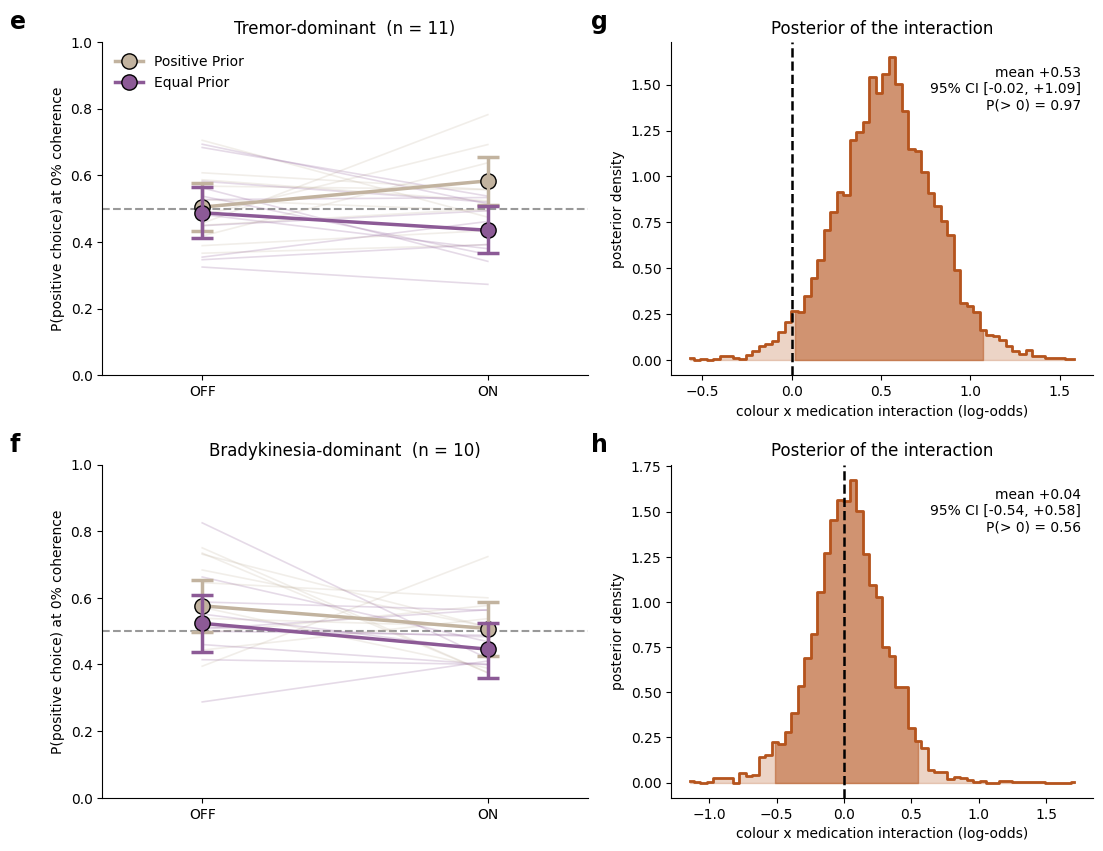

In [6]:
PRIOR_COLOR, EQUAL_COLOR = "#C2B39F", "#8C5A96"
SUBTYPE_LABEL = {"tremor": "Tremor-dominant", "bradykinetic": "Bradykinesia-dominant"}


def predicted_probability(samples, colour, medication):
    """Posterior of P(positive choice) at 0% coherence and neutral history."""
    eta = (samples[:, TERMS.index("intercept")]
           + colour * samples[:, TERMS.index("col")]
           + medication * samples[:, TERMS.index("med")]
           + colour * medication * samples[:, TERMS.index("col:med")])
    return 1 / (1 + np.exp(-eta))


def observed_bias(subset):
    """Each subject's observed choice proportion at 0% coherence, per condition."""
    zero = subset[subset["coherence"] == 0]
    return zero.groupby(["subject_id", "med", "col"])["choice"].mean()


fig, axes = plt.subplots(2, 2, figsize=(11, 8.6),
                         gridspec_kw={"width_ratios": [1.15, 1]})
panel_letters = [["e", "g"], ["f", "h"]]

for row, (name, subset) in enumerate(subsets.items()):
    samples = posterior[name]
    ax = axes[row, 0]
    observed = observed_bias(subset)

    for colour_value, colour, label in [(0.5, PRIOR_COLOR, "Positive Prior"),
                                        (-0.5, EQUAL_COLOR, "Equal Prior")]:
        means, lows, highs = [], [], []
        for medication in (-0.5, 0.5):
            draws = predicted_probability(samples, colour_value, medication)
            means.append(draws.mean())
            low, high = np.percentile(draws, [2.5, 97.5])
            lows.append(low); highs.append(high)
        ax.plot([0, 1], means, "-o", color=colour, ms=11, mec="k", lw=2.5, zorder=4, label=label)
        ax.errorbar([0, 1], means, yerr=[np.array(means) - lows, np.array(highs) - np.array(means)],
                    color=colour, lw=2.5, capsize=8, capthick=2.5, ls="", zorder=4)
        for subject in subset["subject_id"].unique():
            try:
                pair = [observed.loc[(subject, m, colour_value)] for m in (-0.5, 0.5)]
            except KeyError:
                continue
            ax.plot([0, 1], pair, color=colour, alpha=0.22, lw=1.2, zorder=2)

    ax.axhline(0.5, color="0.6", ls="--", lw=1.5, zorder=0)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["OFF", "ON"])
    ax.set_xlim(-0.35, 1.35); ax.set_ylim(0, 1)
    ax.set_ylabel("P(positive choice) at 0% coherence")
    ax.set_title(f"{SUBTYPE_LABEL[name]}  (n = {subset['subject_id'].nunique()})", fontsize=12)
    ax.annotate(panel_letters[row][0], (-0.19, 1.04), xycoords="axes fraction",
                fontsize=17, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    if row == 0:
        ax.legend(frameon=False, loc="upper left", fontsize=10)

    # posterior of the interaction
    ax = axes[row, 1]
    draws = samples[:, TERMS.index("col:med")]
    low, high = np.percentile(draws, [2.5, 97.5])
    counts, edges = np.histogram(draws, bins=60, density=True)
    centres = (edges[:-1] + edges[1:]) / 2
    ax.fill_between(centres, counts, color="#B5541D", alpha=0.25, step="mid")
    ax.plot(centres, counts, color="#B5541D", lw=2, drawstyle="steps-mid")
    inside = (centres >= low) & (centres <= high)
    ax.fill_between(centres[inside], counts[inside], color="#B5541D", alpha=0.5, step="mid")
    ax.axvline(0, color="k", ls="--", lw=1.8)
    ax.set_xlabel("colour x medication interaction (log-odds)")
    ax.set_ylabel("posterior density")
    ax.set_title("Posterior of the interaction", fontsize=12)
    ax.annotate(panel_letters[row][1], (-0.19, 1.04), xycoords="axes fraction",
                fontsize=17, fontweight="bold")
    ax.annotate(f"mean {draws.mean():+.2f}\n95% CI [{low:+.2f}, {high:+.2f}]\n"
                f"P(> 0) = {(draws > 0).mean():.2f}",
                (0.97, 0.93), xycoords="axes fraction", ha="right", va="top", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
figure_path = Path("figure2ef_replacement.pdf")
fig.savefig(figure_path, bbox_inches="tight")
fig.savefig(figure_path.with_suffix(".png"), dpi=200, bbox_inches="tight")
print(f"saved {figure_path} and .png")
plt.show()


## 4. Caption

Panel letters assume this replaces 2e,f and adds two panels. Renumber if you keep a different layout.


In [7]:
tremor_draws = posterior["tremor"][:, TERMS.index("col:med")]
brady_draws = posterior["bradykinetic"][:, TERMS.index("col:med")]
t_low, t_high = np.percentile(tremor_draws, [2.5, 97.5])
b_low, b_high = np.percentile(brady_draws, [2.5, 97.5])

caption = f"""
(e,f) Trial-level hierarchical logistic regression of single-trial choices,
choice ~ coherence + colour x medication + trial-history terms, with by-subject deviations on every
population-level effect, fit by Hamiltonian Monte Carlo (4 chains, 1,000 tuning and 1,000 sampling
iterations each). Points show the posterior mean predicted probability of a positive-orientation
choice at 0% coherence for Positive-Prior (khaki) and Equal-Prior (purple) trials, OFF versus ON
medication; error bars are 95% posterior credible intervals. Thin lines are individual subjects'
observed choice proportions at 0% coherence. (e) Tremor-dominant patients
(n = {subsets['tremor']['subject_id'].nunique()}, {len(subsets['tremor']):,} trials).
(f) Bradykinesia-dominant patients
(n = {subsets['bradykinetic']['subject_id'].nunique()}, {len(subsets['bradykinetic']):,} trials).
(g,h) Full posterior distribution of the colour x medication interaction for each subtype, with the
95% credible interval shaded and zero marked by the dashed line. In tremor-dominant patients the
interaction is positive with posterior mean {tremor_draws.mean():+.2f} log-odds
(95% CI [{t_low:+.2f}, {t_high:+.2f}]) and posterior probability {(tremor_draws > 0).mean():.2f} of
being greater than zero; the credible interval includes zero, so the evidence that medication
changes prior use is suggestive rather than conclusive at this sample size. In
bradykinesia-dominant patients the interaction is centred near zero
({brady_draws.mean():+.2f}, 95% CI [{b_low:+.2f}, {b_high:+.2f}]).
""".strip()

print(caption)


(e,f) Trial-level hierarchical logistic regression of single-trial choices,
choice ~ coherence + colour x medication + trial-history terms, with by-subject deviations on every
population-level effect, fit by Hamiltonian Monte Carlo (4 chains, 1,000 tuning and 1,000 sampling
iterations each). Points show the posterior mean predicted probability of a positive-orientation
choice at 0% coherence for Positive-Prior (khaki) and Equal-Prior (purple) trials, OFF versus ON
medication; error bars are 95% posterior credible intervals. Thin lines are individual subjects'
observed choice proportions at 0% coherence. (e) Tremor-dominant patients
(n = 11, 13,518 trials).
(f) Bradykinesia-dominant patients
(n = 10, 12,529 trials).
(g,h) Full posterior distribution of the colour x medication interaction for each subtype, with the
95% credible interval shaded and zero marked by the dashed line. In tremor-dominant patients the
interaction is positive with posterior mean +0.53 log-odds
(95% CI [-0.02, +1.

## 5. Methods text


In [8]:
methods = f"""
Trial-level mixed-effects model. Collapsing each subject's data to a single psychometric bias
estimate per condition discards trial-level information and is underpowered given the size of the
patient subgroups. We therefore additionally modelled single-trial choices with a hierarchical
logistic regression, choice ~ coherence + colour x medication, with colour (Positive versus Equal
Prior) and medication (ON versus OFF) effect-coded so that their interaction is a trial-level
analogue of the subject-level difference-in-differences contrast, coherence included as a covariate
to account for the psychometric slope, and previous-trial terms included to prevent sequential
effects from loading onto the interaction. The model included by-subject deviations on every
population-level effect, so that between-subject variability in medication response is not treated
as precision on the population-level estimate.

Models were fit by Hamiltonian Monte Carlo (No-U-Turn sampler) in PyMC, using a non-centred
parameterisation, weakly informative Normal(0, 2.5) priors on population-level effects and
half-Normal(1) priors on the by-subject scales, with four chains of 1,000 tuning and 1,000 sampling
iterations. All parameters had R-hat <= {max(diagnostics['max r_hat']):.3f} and bulk effective
sample sizes >= {int(min(diagnostics['min ESS (bulk)']))}, with
{int(diagnostics['divergences'].sum())} divergent transitions. Effects are summarised by the
posterior mean, the 95% credible interval, and the posterior probability that the effect exceeds
zero; we do not dichotomise these into significant and non-significant.

We initially fit this model by mean-field variational inference. Calibration analysis showed that
approximation to be unreliable at this sample size: on datasets constructed to satisfy the null by
randomly exchanging each patient's OFF and ON labels, it rejected at a nominal 5% level in
approximately 52% of cases, and its posterior standard deviations were roughly three times narrower
than those obtained by Hamiltonian Monte Carlo on the same data. All reported trial-level estimates
therefore come from the sampled posterior.
""".strip()

print(methods)


Trial-level mixed-effects model. Collapsing each subject's data to a single psychometric bias
estimate per condition discards trial-level information and is underpowered given the size of the
patient subgroups. We therefore additionally modelled single-trial choices with a hierarchical
logistic regression, choice ~ coherence + colour x medication, with colour (Positive versus Equal
Prior) and medication (ON versus OFF) effect-coded so that their interaction is a trial-level
analogue of the subject-level difference-in-differences contrast, coherence included as a covariate
to account for the psychometric slope, and previous-trial terms included to prevent sequential
effects from loading onto the interaction. The model included by-subject deviations on every
population-level effect, so that between-subject variability in medication response is not treated
as precision on the population-level estimate.

Models were fit by Hamiltonian Monte Carlo (No-U-Turn sampler) in PyMC, using a non-ce

In [9]:
output_path = Path("figure2ef_replacement_text.md")
output_path.write_text(f"# Replacement Figure 2e-h\n\n## Caption\n\n{caption}\n\n## Methods\n\n{methods}\n")
print(f"wrote {output_path.resolve()}")


wrote /src/notebooks/figure2ef_replacement_text.md


## 6. Leave-one-subject-out

The published sensitivity check refits the model with each subject held out and counts how many
refits stay significant. Those counts were computed from variational p-values and inherit the
calibration problem, so they are regenerated here against the sampled posterior.

The question also changes slightly. With a posterior rather than a p-value, the useful summary is
not how many refits cross a threshold but how stable the estimate is: does the posterior mean move
much, does the sign ever flip, and does the posterior probability stay high.

Sensitivity refits use 500 draws per chain rather than 1,000. That is ample for a posterior mean and
a tail probability, and keeps the 21 refits to about half an hour.


In [10]:
loso_records = []
for subtype, subset in subsets.items():
    for held_out in sorted(subset["subject_id"].unique()):
        reduced = subset[subset["subject_id"] != held_out].reset_index(drop=True)
        reduced_idata = fit_mcmc(reduced, draws=500, tune=1000, seed=1)
        draws = reduced_idata.posterior["beta"].values.reshape(-1, len(TERMS))[:, TERMS.index("col:med")]
        low, high = np.percentile(draws, [2.5, 97.5])
        loso_records.append({
            "subtype": subtype, "held_out": held_out,
            "mean": draws.mean(), "SD": draws.std(), "2.5%": low, "97.5%": high,
            "P(> 0)": (draws > 0).mean(),
            "CI excludes 0": bool(low > 0 or high < 0),
            "divergences": int(reduced_idata.sample_stats["diverging"].values.sum()),
        })

loso = pd.DataFrame(loso_records)
loso.set_index(["subtype", "held_out"]).round(4)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 84 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 83 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 80 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 80 sec

mean      SD    2.5%   97.5%  P(> 0)  CI excludes 0  \
subtype      held_out                                                          
tremor       P11       0.5485  0.3103 -0.0147  1.2005  0.9730          False   
             P12       0.4792  0.3221 -0.1791  1.1169  0.9315          False   
             P17       0.4222  0.2840 -0.1900  0.9710  0.9330          False   
             P18       0.5797  0.3035 -0.0431  1.1755  0.9710          False   
             P19       0.5578  0.3042 -0.0387  1.1552  0.9695          False   
             P29       0.4670  0.3121 -0.1284  1.0820  0.9395          False   
             P3        0.5196  0.3101 -0.0852  1.1054  0.9580          False   
             P31       0.7043  0.2368  0.2514  1.1967  0.9990           True   
             P32       0.5403  0.3183 -0.1229  1.1920  0.9535          False   
             P6        0.4080  0.2697 -0.1143  0.9230  0.9435          False   
             P7        0.5644  0.2956  0.0099  1.1588  0.9775           True   
bradykinetic P1       -0.1063  0.2632 -0.6223  0.4196  0.3325          False   
             P13       0.0459  0.3218 -0.5856  0.6962  0.5655          False   
             P20       0.0100  0.3125 -0.6331  0.6280  0.5155          False   
             P22       0.1892  0.2702 -0.3587  0.7591  0.7790          False   
             P23       0.1283  0.2897 -0.4762  0.7125  0.6905          False   
             P28      -0.0236  0.3019 -0.6218  0.5953  0.4695          False   
             P33       0.0919  0.3002 -0.5343  0.6581  0.6410          False   
             P34       0.0269  0.3002 -0.5732  0.6402  0.5280          False   
             P4        0.1081  0.2895 -0.4592  0.6890  0.6640          False   
             P9       -0.0481  0.2972 -0.6163  0.5720  0.4175          False   

                       divergences  
subtype      held_out               
tremor       P11                 0  
             P12                 0  
             P17                 0  
             P18                 0  
             P19                 0  
             P29                 0  
             P3                  0  
             P31                 0  
             P32                 0  
             P6                  0  
             P7                  0  
bradykinetic P1                  0  
             P13                 0  
             P20                 0  
             P22                 0  
             P23                 0  
             P28                 0  
             P33                 0  
             P34                 0  
             P4                  0  
             P9                  0

### Stability summary


In [11]:
stability_rows = []
for subtype, block in loso.groupby("subtype"):
    full_draws = posterior[subtype][:, TERMS.index("col:med")]
    full_mean = full_draws.mean()
    stability_rows.append({
        "subtype": subtype,
        "full-data mean": full_mean,
        "refits": len(block),
        "mean range": f"{block['mean'].min():+.3f} to {block['mean'].max():+.3f}",
        "same sign as full": int((np.sign(block["mean"]) == np.sign(full_mean)).sum()),
        "P(> 0) range": f"{block['P(> 0)'].min():.2f} to {block['P(> 0)'].max():.2f}",
        "CI excludes 0": int(block["CI excludes 0"].sum()),
        "total divergences": int(block["divergences"].sum()),
    })

pd.DataFrame(stability_rows).set_index("subtype")


,full-data mean,refits,mean range,same sign as full,P(> 0) range,CI excludes 0,total divergences
subtype,,,,,,,
bradykinetic,0.037010,10,-0.106 to +0.189,7,0.33 to 0.78,0,0
tremor,0.531144,11,+0.408 to +0.704,11,0.93 to 1.00,2,0


### Figure. Leave-one-subject-out estimates


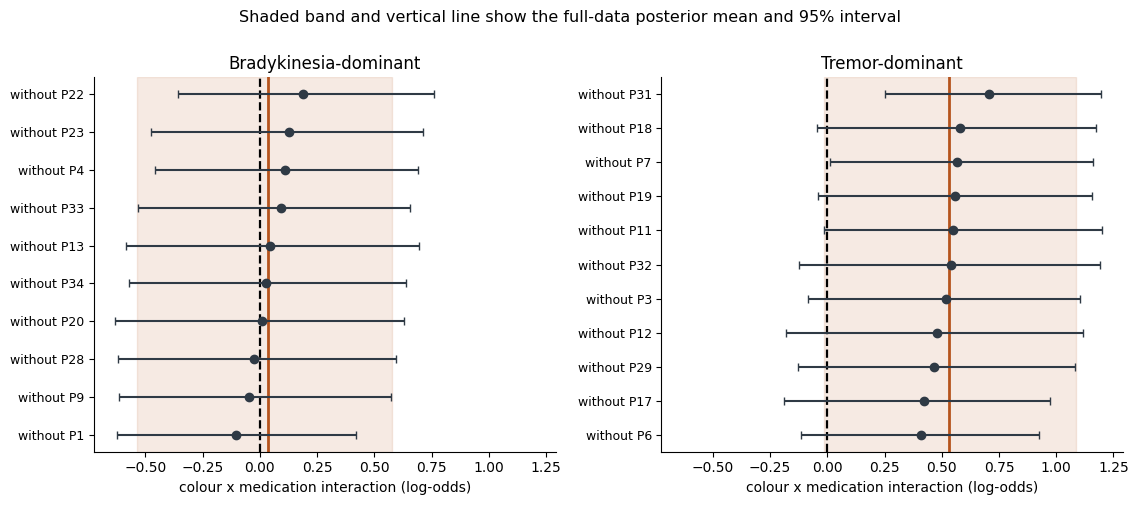

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5), sharex=True)

for ax, (subtype, block) in zip(axes, loso.groupby("subtype")):
    block = block.sort_values("mean").reset_index(drop=True)
    full_draws = posterior[subtype][:, TERMS.index("col:med")]
    full_low, full_high = np.percentile(full_draws, [2.5, 97.5])

    ax.axvspan(full_low, full_high, color="#B5541D", alpha=0.12, zorder=0)
    ax.axvline(full_draws.mean(), color="#B5541D", lw=2, zorder=1)
    ax.axvline(0, color="k", ls="--", lw=1.6, zorder=1)

    positions = np.arange(len(block))
    ax.errorbar(block["mean"], positions,
                xerr=[block["mean"] - block["2.5%"], block["97.5%"] - block["mean"]],
                ls="", marker="o", ms=6, color="#2F3A45", capsize=3, lw=1.5)
    ax.set_yticks(positions)
    ax.set_yticklabels([f"without {s}" for s in block["held_out"]], fontsize=9)
    ax.set_xlabel("colour x medication interaction (log-odds)")
    ax.set_title(f"{SUBTYPE_LABEL[subtype]}", fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Shaded band and vertical line show the full-data posterior mean and 95% interval",
             fontsize=11.5, y=1.0)
fig.tight_layout()
fig.savefig("figure2ef_leave_one_out.pdf", bbox_inches="tight")
plt.show()


### Replacement text for the sensitivity check

Use this in place of the sentence reporting how many leave-one-out refits stayed significant.


In [13]:
tremor_block = loso[loso["subtype"] == "tremor"]
brady_block = loso[loso["subtype"] == "bradykinetic"]
full_tremor = posterior["tremor"][:, TERMS.index("col:med")].mean()

sensitivity_text = f"""
As a robustness check, the model was refit with each subject excluded in turn. In tremor-dominant
patients the colour x medication interaction retained the same sign in
{int((np.sign(tremor_block['mean']) == np.sign(full_tremor)).sum())} of {len(tremor_block)} refits,
with posterior means ranging from {tremor_block['mean'].min():+.2f} to
{tremor_block['mean'].max():+.2f} log-odds (full-data estimate {full_tremor:+.2f}) and posterior
probability of a positive effect ranging from {tremor_block['P(> 0)'].min():.2f} to
{tremor_block['P(> 0)'].max():.2f}. The 95% credible interval excluded zero in
{int(tremor_block['CI excludes 0'].sum())} of {len(tremor_block)} refits. The direction of the
effect is therefore stable across subject exclusions, while its magnitude remains imprecisely
estimated at this sample size. In bradykinesia-dominant patients the interaction remained centred
near zero in all {len(brady_block)} refits (posterior means {brady_block['mean'].min():+.2f} to
{brady_block['mean'].max():+.2f}).
""".strip()

print(sensitivity_text)
Path("figure2ef_replacement_text.md").write_text(
    Path("figure2ef_replacement_text.md").read_text()
    + f"\n\n## Sensitivity check\n\n{sensitivity_text}\n")
print("\nappended to figure2ef_replacement_text.md")


As a robustness check, the model was refit with each subject excluded in turn. In tremor-dominant
patients the colour x medication interaction retained the same sign in
11 of 11 refits,
with posterior means ranging from +0.41 to
+0.70 log-odds (full-data estimate +0.53) and posterior
probability of a positive effect ranging from 0.93 to
1.00. The 95% credible interval excluded zero in
2 of 11 refits. The direction of the
effect is therefore stable across subject exclusions, while its magnitude remains imprecisely
estimated at this sample size. In bradykinesia-dominant patients the interaction remained centred
near zero in all 10 refits (posterior means -0.11 to
+0.19).

appended to figure2ef_replacement_text.md


## 7. How to interpret and describe this

### What the panel now says

The interaction is positive, sizeable, and uncertain. The posterior mean is a little over half a
log-odds, the bulk of the posterior is positive, and the 95% credible interval includes zero. With
11 patients, the data constrain the direction of the effect much better than its existence.

### Wording that is defensible

> Medication increased the influence of the colour prior in tremor-dominant patients (posterior mean
> +0.53 log-odds, 95% CI [-0.02, 1.09]), with 97% posterior probability that the effect is positive.
> No comparable effect was present in bradykinesia-dominant patients.

### Wording that is not

> The colour x medication interaction was highly significant in the tremor-dominant group
> (p = 7.48e-9).

That p-value comes from an approximation that rejects true nulls half the time. Also avoid "medication
restored prior use" as an unqualified causal claim, and avoid resting the argument on the fact that
the prior effect is significant ON medication but not OFF. A difference in significance is not a
significant difference, and the interaction is the test that speaks to it.

### If a reviewer asks whether the effect is real

Four independent analyses agree on direction and magnitude and disagree only about whether the
threshold is crossed: this posterior, a subject-level difference-in-differences, a sign-flip
randomisation test, and a cluster-robust logistic regression. Convergent direction across methods
with a marginal interval is a power limitation, not a contradiction. Say so plainly rather than
picking whichever test crosses 0.05.

### What is unaffected

Every subject-level test in the paper. The positive-versus-equal prior contrasts within each group,
the drift-diffusion parameter comparisons, and the GLM-HMM occupancy tests all operate on one value
per subject and were shown to be correctly calibrated. Those results stand as published.

### One thing to rerun

The leave-one-subject-out sensitivity check in the current manuscript counts how many refits stayed
significant, using the variational p-values. Those counts inherit the calibration problem and need
regenerating against this posterior before they can be quoted.
